**Linear Regression**

**Y=wX + b**

Y --> Dependent Veriable

X --> Independent Veriable

w --> weight

b --> Bias

**Gradient Dencent:**

Gredient Descent is an optimization algorithem used for minimizing the loss functin in verious machine learning algorithems it is used for updating the parameters of the learning model

w = w - a*dw

b = b - a*db

**Learning Rate:**

Learning rate is a tuining parameter in an optimization algorithem that determines the step size at each iteration while moving toward of a loss function


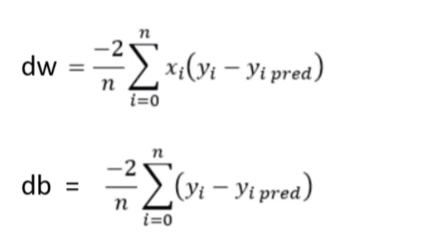



Work flow of the Linear Regression model:

Step 1: Set Learning Rate & Number of Iterations; Initiate Random weight and bias value.

Step 2: Build Linear Regression Equation. (y = wx + b)

Step 3: Find the "y pred" value for given x value for the corresponding weight & bias.

Step 4: Check the loss function for these parameter values. ( difference between "y pred" & "true y")

Step 5: Update the parameter values using Gradient Descent. (new weight & bias value)

Step 6: Step 3, 4, 5 are repeated till we get minimum loss function

Finally we will get the best model (best weight and bias value) as it has minimum loss function.

In [ ]:
#importing numpy library
import numpy as np

**Linear Regression**

In [ ]:
class Linear_Regression():

#initiating the parameters (learning rate and no of iteration)
  def __init__(self, learning_rate, no_of_iterations):
    self.learning_rate = learning_rate
    self.no_of_iterations = no_of_iterations

  def fit(self,X , Y):

    # number of training examples and no of feature
    self.m, self.n = X.shape # numbers of rows(m) and columns (n)

    #initiating the weight and bias
    self.w = np.zeros(self.n)
    self.b = 0
    self.X = X
    self.Y = Y

    #implementing Gradient Desent
    for i in range(self.no_of_iterations):
        self.update_weights()


  def update_weights(self, ):

    Y_prediction = self.predict(self.X)

    #calculate Gradients
    dw = - (2 * (self.X.T).dot(self.Y - Y_prediction)) / self.m
    db = - 2 * np.sum(self.Y - Y_prediction) / self.m

    # updating the weights
    self.w = self.w - self.learning_rate * dw
    self.b = self.b - self.learning_rate * db

  def predict(self, X):
    return X.dot(self.w) + self.b


Using linera regression for prediction


In [ ]:
# importhing dependencies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split

data preprocessing

In [ ]:
data = pd.read_csv('/content/salary_data.csv')

In [ ]:
data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [ ]:
data.shape

(30, 2)

In [ ]:
data.isnull().sum()

,0
YearsExperience,0
Salary,0


In [ ]:
#X = data.drop(["Salary"], axis = 1)
#Y = data["Salary"]


X = data.iloc[:,:-1].values
Y = data.iloc[:,1].values

print(X)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]


In [ ]:
print(Y)

[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


In [ ]:
X_test , X_train , Y_test , Y_train = train_test_split(X, Y, test_size = 0.33 , random_state = 2)

Training the linear regression model

In [ ]:
model = Linear_Regression(learning_rate= 0.02 , no_of_iterations = 100000)

In [ ]:
model.fit(X_train , Y_train)

In [ ]:
# printing the parameters value(weight and bias)

print("weight: " , model.w[0])
print("bias: " , model.b)

weight:  10105.30590017192
bias:  26368.413216248668


Y = 10105(X) + 26365

Salary = 10105 (Experience) + 26365

In [ ]:
test_data_prediction = model.predict(X_test)

In [ ]:
print(test_data_prediction)

[ 55673.80032675 123379.3498579   66789.63681694  48600.08619663
  65779.10622692  77905.47330713 130453.06398802 117316.1663178
  79926.53448716  41526.37206651  58705.3920968  122368.81926788
 114284.57454774  85989.71802726  66789.63681694 106200.32982761
 132474.12516805  67800.16740695  75884.41212709  58705.3920968 ]


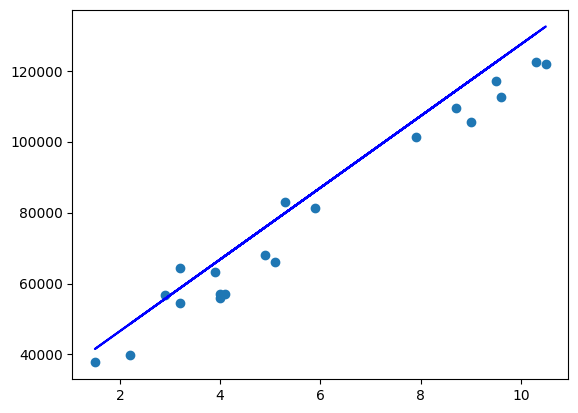

In [ ]:
plt.scatter(X_test , Y_test)
plt.plot(X_test , test_data_prediction , color = 'blue')